# 2. Spatial processing

### GBIF

This notebook reads in the shapefile for administrative regions from here https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-1-states-provinces/, and the `gbif_processed.parquet` file from notebook #1, and outputs a gbif biodiversity dataset with 'state' column for German Bundeslaender, based on Lat/Long coordinates.

'stateProvince' in gbif data is very messy (see part 2a below) - don't use it. Instead, assign states using lat/long coordinates and polygons for administrative regions

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd

Explore shapefile and extract only polygons for Germany

In [2]:
gdf = gpd.read_file("../Data/Raw/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp")
print(gdf.columns)
print(gdf.head())

Index(['featurecla', 'scalerank', 'adm1_code', 'diss_me', 'iso_3166_2',
       'wikipedia', 'iso_a2', 'adm0_sr', 'name', 'name_alt',
       ...
       'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT', 'FCLASS_NL',
       'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'FCLASS_TLC', 'geometry'],
      dtype='str', length=122)
                 featurecla  scalerank adm1_code  diss_me iso_3166_2  \
0  Admin-1 states provinces          3  ARG-1309     1309       AR-E   
1  Admin-1 states provinces          6     URY-8        8      UY-PA   
2  Admin-1 states provinces          2  IDN-1185     1185      ID-KI   
3  Admin-1 states provinces          6  MYS-1186     1186      MY-12   
4  Admin-1 states provinces          3  CHL-2694     2694      CL-AP   

  wikipedia iso_a2  adm0_sr                name      name_alt  ... FCLASS_ID  \
0       NaN     AR        1          Entre Ríos    Entre-Rios  ...       NaN   
1       NaN     UY        1            Paysandú           NaN  ...       NaN   
2      

In [3]:
germany = gdf.loc[gdf['admin'].str.contains('Germany', case=False, na=False)]
germany.head()

,featurecla,scalerank,adm1_code,diss_me,iso_3166_2,wikipedia,iso_a2,adm0_sr,name,name_alt,...,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,FCLASS_TLC,geometry
117,Admin-1 states provinces,3,DEU-1601,1601,DE-SN,NaN,DE,1,Sachsen,Saxony,...,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,"POLYGON ((14.39781 51.01311, 14.38675 51.01327..."
120,Admin-1 states provinces,3,DEU-1591,1591,DE-BY,NaN,DE,1,Bayern,Bavaria,...,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,"POLYGON ((12.10134 50.31398, 12.07614 50.31517..."
195,Admin-1 states provinces,3,DEU-1580,1580,DE-RP,NaN,DE,1,Rheinland-Pfalz,Rhineland-Palatinate,...,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,"POLYGON ((6.10116 50.06341, 6.0994 50.06413, 6..."
198,Admin-1 states provinces,3,DEU-1581,1581,DE-SL,NaN,DE,1,Saarland,NaN,...,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,"POLYGON ((6.34531 49.45535, 6.34538 49.46272, ..."
268,Admin-1 states provinces,3,DEU-1579,1579,DE-SH,NaN,DE,6,Schleswig-Holstein,NaN,...,NaN,None,NaN,NaN,None,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((8.82425 54.9059, 8.90414 54.89..."


Visualise polygons for Germany

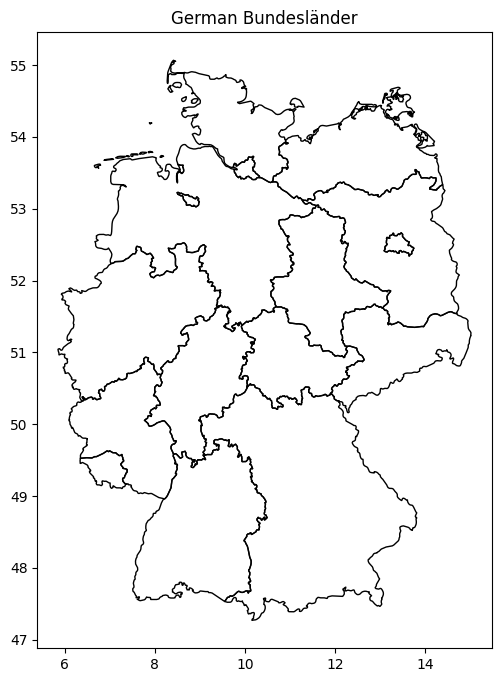

In [4]:
import matplotlib.pyplot as plt

germany.plot(
    figsize=(8, 8),
    edgecolor="black",
    linewidth=1,
    facecolor="none"
)
plt.title("German Bundesländer")
plt.show()

Add states column to gbif data

In [5]:
# load parquet file of gbif data

gbif = pd.read_parquet("../Data/Processed/gbif_processed.parquet")

In [8]:
# Convert df to geodataframe

# Convert points to geometry
geo_gbif = gpd.GeoDataFrame(
    gbif,
    geometry=gpd.points_from_xy(gbif.decimalLongitude, gbif.decimalLatitude),
    crs="EPSG:4326"
)

In [10]:
# Spatial join to add state from shapefile

# Perform point-in-polygon join
geo_gbif = gpd.sjoin(
    geo_gbif,
    germany[['name', 'geometry']],  # only keep the state name and geometry
    how='left',                     # keep all GBIF points
    predicate='within'              # point must be within state polygon
)

# Rename the state column for clarity
geo_gbif = geo_gbif.rename(columns={'name': 'state'})


In [12]:
# Drop extra columns from sjoin (index_right)
geo_gbif = geo_gbif.drop(columns=['index_right', 'decimalLatitude', 'decimalLongitude', 'basisOfRecord', 'geometry'])

In [13]:
geo_gbif.head()

,gbifID,species,month,year,state
0,4508288286,Oxygastra curtisii,7,2013,Rheinland-Pfalz
1,4508285279,Oxygastra curtisii,6,2014,Rheinland-Pfalz
2,1950685555,Conistra vaccinii,4,2004,Saarland
3,1950685917,Leptidea sinapis,4,2004,Saarland
4,1950685708,Scoliopteryx libatrix,4,2004,Rheinland-Pfalz


Sense check

In [14]:
geo_gbif['state'].value_counts()

state
Nordrhein-Westfalen       4922975
Niedersachsen             3892447
Bayern                    3641298
Baden-Württemberg         3279906
Hessen                    3274938
Rheinland-Pfalz           2725209
Schleswig-Holstein        1610636
Sachsen                   1368943
Brandenburg               1168973
Mecklenburg-Vorpommern     869847
Berlin                     816690
Thüringen                  740872
Sachsen-Anhalt             611063
Hamburg                    304604
Saarland                   193100
Bremen                     152971
Name: count, dtype: int64

Check for NAs

In [4]:
geo_gbif[geo_gbif['state'].isna()].sample(10)

,gbifID,species,month,year,state
6628181,2681248241,Sylvia atricapilla,4,2019,NaN
29899461,4986581069,Passer domesticus,10,2024,NaN
10640593,3466539112,Larus canus,1,2022,NaN
7713410,2686299339,Turdus philomelos,10,2015,NaN
5161488,5701807080,Passer domesticus,10,2024,NaN
27643414,3995975372,Pluvialis squatarola,10,2022,NaN
27355526,4956620216,Nezara viridula,10,2024,NaN
1049245,4114525930,Melanitta fusca,3,2004,NaN
1051098,4114269054,Larus fuscus,7,2011,NaN
5057601,3180320135,Sturnus vulgaris,9,2020,NaN


Remove NAs

In [5]:
print(geo_gbif.shape)
geo_gbif = geo_gbif.dropna().copy()
print(geo_gbif.shape)

(30621074, 5)
(29574472, 5)


Save to parquet

In [6]:
geo_gbif.to_parquet('../Data/Processed/gbif_states.parquet', index=False)

---

### 2a - Messy stateProvince data from gbif data

Extract distinct stateProvince from data for weather API requests

In [17]:
import duckdb

In [18]:
gbif = '../data/raw/gbif_raw.csv'

states_df = duckdb.query(f"""
SELECT DISTINCT stateProvince AS states
FROM read_csv('{gbif}', quote='', escape='')
""").to_df()

In [19]:
states_df

,states
0,Baden-Wuerttemberg
1,Saxony
2,Berlin
3,MECKLENBURG-VORPOMMERN
4,Thüringen
...,...
197,Тюрингия
198,Meclenburg-Vorpommern
199,Steigerwald
200,Nordbaden


In [20]:
# clean states (remove ', Germany')
states_df['states'] = states_df['states'].str.split(',').str[0]

In [21]:
states_df['states'].unique()

array(['Baden-Wuerttemberg', 'Saxony', 'Berlin', 'MECKLENBURG-VORPOMMERN',
       'Thüringen', 'Limburg', 'Carinthia', 'Karlsruhe', 'Rheinland',
       'Mecklenburg Vorpommern', 'Zollernalbkreis district', 'Hessen',
       'Baden-Württemberg', 'Baden-W?rttemberg', 'Rheinhessen-Pfalz', nan,
       'Hannover', 'Leipzig', 'Bayern', 'Germany', 'Düsseldorf',
       'Schleswig-Holstein', 'Thurgau', 'Dohnatal', 'Chemnitz',
       'Clervaux', 'Unterfranken', 'Nordrhein-Westfalen',
       'Rheinland-Pfalz', 'Mecklenburg-Vorpomm.',
       'Germany-Luxembourg condominium', 'Baden-Wurttemberg State',
       'Breisgau-Hochschwarzwald', 'Niederbayern', 'Bavaria',
       'Mecklenburg-Pommerania', 'Nw', 'Meckelenburg Vorpommern',
       'Hampuri', 'Other', 'Mittelfranken', 'Saarland', 'Salzburg',
       'Hainich', 'Western Greece', 'Munich', 'Upper Palatinate',
       'Berlín', 'unsure', 'North Rhine-Westphalia', 'SCHLESWIG-HOLSTEIN',
       'Detmold', 'Arnsberg', 'Oberpfalz', 'NORDRHEIN-WESTFALEN',
 

States are very messy. Use geopandas for spatial joins with polygons based on lats and longs in data